In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
actual_df = pd.read_csv("../../data/raw/raw_weather_daily.csv")

actual_df["time"] = pd.to_datetime(actual_df["time"])

actual_df = actual_df.rename(columns={
    "time": "date",
    "temperature_2m_max": "actual_max_temp"
})

actual_df = actual_df[["date", "actual_max_temp"]]

actual_df.head()

,date,actual_max_temp
0,2022-01-01,27.8
1,2022-01-02,27.1
2,2022-01-03,27.3
3,2022-01-04,27.0
4,2022-01-05,27.6


In [3]:
print(actual_df.shape)
print(actual_df["date"].min())
print(actual_df["date"].max())
print(actual_df.isnull().sum())

(1461, 2)
2022-01-01 00:00:00
2025-12-31 00:00:00
date               0
actual_max_temp    0
dtype: int64


In [4]:
url = "https://previous-runs-api.open-meteo.com/v1/forecast"

params = {
    "latitude": 17.3850,
    "longitude": 78.4867,
    "start_date": "2024-01-01",
    "end_date": "2025-12-31",
    "hourly": ",".join([
        "temperature_2m",
        "temperature_2m_previous_day1",
        "temperature_2m_previous_day3",
        "temperature_2m_previous_day7"
    ]),
    "timezone": "Asia/Kolkata"
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

response.raise_for_status()

forecast_data = response.json()

print(forecast_data.keys())

Status code: 200
dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [5]:
forecast_df = pd.DataFrame(forecast_data["hourly"])

forecast_df["time"] = pd.to_datetime(forecast_df["time"])

forecast_df.head()

,time,temperature_2m,temperature_2m_previous_day1,temperature_2m_previous_day3,temperature_2m_previous_day7
0,2024-01-01 00:00:00,17.3,NaN,NaN,NaN
1,2024-01-01 01:00:00,16.6,NaN,NaN,NaN
2,2024-01-01 02:00:00,15.7,NaN,NaN,NaN
3,2024-01-01 03:00:00,15.5,NaN,NaN,NaN
4,2024-01-01 04:00:00,15.3,NaN,NaN,NaN


In [6]:
print(forecast_df.shape)
print(forecast_df.columns)
print(forecast_df.isnull().sum())

(17544, 5)
Index(['time', 'temperature_2m', 'temperature_2m_previous_day1',
       'temperature_2m_previous_day3', 'temperature_2m_previous_day7'],
      dtype='str')
time                              0
temperature_2m                    0
temperature_2m_previous_day1    449
temperature_2m_previous_day3    497
temperature_2m_previous_day7    593
dtype: int64


In [7]:
forecast_df["date"] = forecast_df["time"].dt.normalize()

daily_forecast_df = (
    forecast_df
    .groupby("date")
    .agg({
        "temperature_2m_previous_day1": "max",
        "temperature_2m_previous_day3": "max",
        "temperature_2m_previous_day7": "max"
    })
    .reset_index()
)

daily_forecast_df.head()

,date,temperature_2m_previous_day1,temperature_2m_previous_day3,temperature_2m_previous_day7
0,2024-01-01,NaN,NaN,NaN
1,2024-01-02,NaN,NaN,NaN
2,2024-01-03,NaN,NaN,NaN
3,2024-01-04,NaN,NaN,NaN
4,2024-01-05,NaN,NaN,NaN


In [8]:
daily_forecast_df = daily_forecast_df.rename(columns={
    "temperature_2m_previous_day1": "forecast_1_day",
    "temperature_2m_previous_day3": "forecast_3_day",
    "temperature_2m_previous_day7": "forecast_7_day"
})

daily_forecast_df.head()

,date,forecast_1_day,forecast_3_day,forecast_7_day
0,2024-01-01,NaN,NaN,NaN
1,2024-01-02,NaN,NaN,NaN
2,2024-01-03,NaN,NaN,NaN
3,2024-01-04,NaN,NaN,NaN
4,2024-01-05,NaN,NaN,NaN


In [9]:
evaluation_df = actual_df.merge(
    daily_forecast_df,
    on="date",
    how="inner"
)

evaluation_df.head()

,date,actual_max_temp,forecast_1_day,forecast_3_day,forecast_7_day
0,2024-01-01,27.7,NaN,NaN,NaN
1,2024-01-02,27.3,NaN,NaN,NaN
2,2024-01-03,27.1,NaN,NaN,NaN
3,2024-01-04,27.7,NaN,NaN,NaN
4,2024-01-05,27.6,NaN,NaN,NaN


In [10]:
print(evaluation_df.shape)
print(evaluation_df.isnull().sum())
print(evaluation_df["date"].min())
print(evaluation_df["date"].max())

(731, 5)
date                0
actual_max_temp     0
forecast_1_day     18
forecast_3_day     20
forecast_7_day     24
dtype: int64
2024-01-01 00:00:00
2025-12-31 00:00:00


In [11]:
evaluation_df["error_1_day"] = (
    evaluation_df["actual_max_temp"]
    - evaluation_df["forecast_1_day"]
).abs()

evaluation_df["error_3_day"] = (
    evaluation_df["actual_max_temp"]
    - evaluation_df["forecast_3_day"]
).abs()

evaluation_df["error_7_day"] = (
    evaluation_df["actual_max_temp"]
    - evaluation_df["forecast_7_day"]
).abs()

In [12]:
evaluation_df.head()

,date,actual_max_temp,forecast_1_day,forecast_3_day,forecast_7_day,error_1_day,error_3_day,error_7_day
0,2024-01-01,27.7,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,27.3,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,27.1,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,27.7,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-05,27.6,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
def calculate_metrics(actual, predicted):
    mask = actual.notna() & predicted.notna()

    actual_valid = actual[mask]
    predicted_valid = predicted[mask]

    mae = mean_absolute_error(actual_valid, predicted_valid)
    mse = mean_squared_error(actual_valid, predicted_valid)
    rmse = np.sqrt(mse)

    return mae, mse, rmse

In [14]:
mae_1, mse_1, rmse_1 = calculate_metrics(
    evaluation_df["actual_max_temp"],
    evaluation_df["forecast_1_day"]
)

mae_3, mse_3, rmse_3 = calculate_metrics(
    evaluation_df["actual_max_temp"],
    evaluation_df["forecast_3_day"]
)

mae_7, mse_7, rmse_7 = calculate_metrics(
    evaluation_df["actual_max_temp"],
    evaluation_df["forecast_7_day"]
)

In [15]:
forecast_comparison = pd.DataFrame({
    "Lead Time": [
        "1 Day",
        "3 Days",
        "7 Days"
    ],
    "MAE": [
        mae_1,
        mae_3,
        mae_7
    ],
    "MSE": [
        mse_1,
        mse_3,
        mse_7
    ],
    "RMSE": [
        rmse_1,
        rmse_3,
        rmse_7
    ]
})

forecast_comparison

,Lead Time,MAE,MSE,RMSE
0,1 Day,0.935344,1.557854,1.248140
1,3 Days,1.176512,2.314866,1.521468
2,7 Days,1.935502,6.304243,2.510825


In [16]:
evaluation_df.to_csv(
    "../results/forecast_evaluation.csv",
    index=False
)

print("Forecast evaluation saved successfully.")

Forecast evaluation saved successfully.


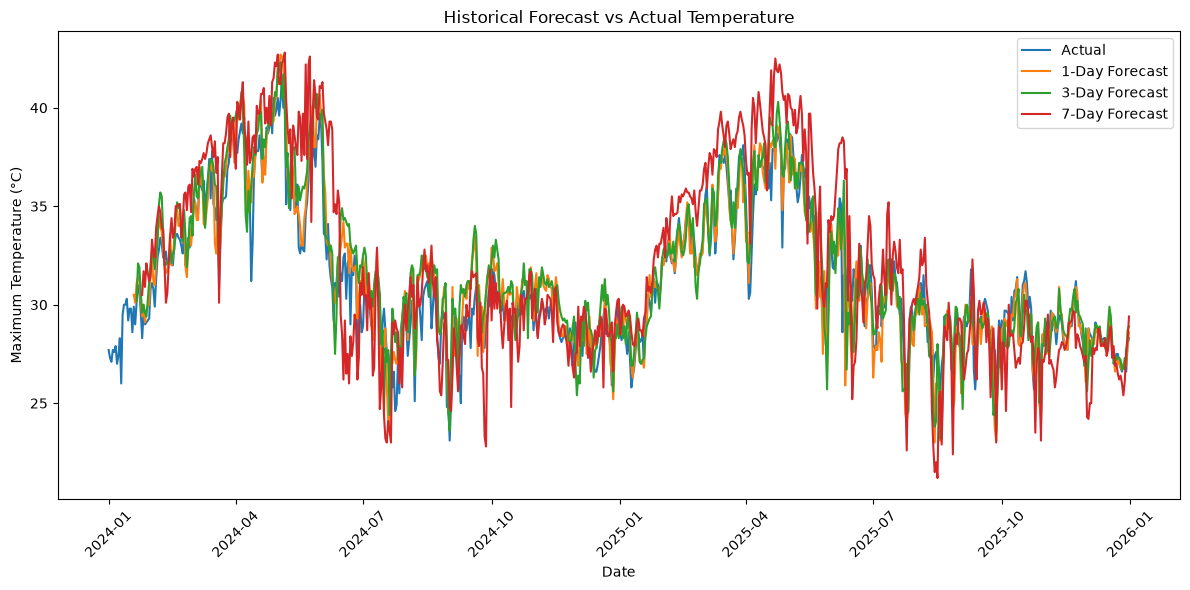

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    evaluation_df["date"],
    evaluation_df["actual_max_temp"],
    label="Actual"
)

plt.plot(
    evaluation_df["date"],
    evaluation_df["forecast_1_day"],
    label="1-Day Forecast"
)

plt.plot(
    evaluation_df["date"],
    evaluation_df["forecast_3_day"],
    label="3-Day Forecast"
)

plt.plot(
    evaluation_df["date"],
    evaluation_df["forecast_7_day"],
    label="7-Day Forecast"
)

plt.xlabel("Date")
plt.ylabel("Maximum Temperature (°C)")
plt.title("Historical Forecast vs Actual Temperature")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

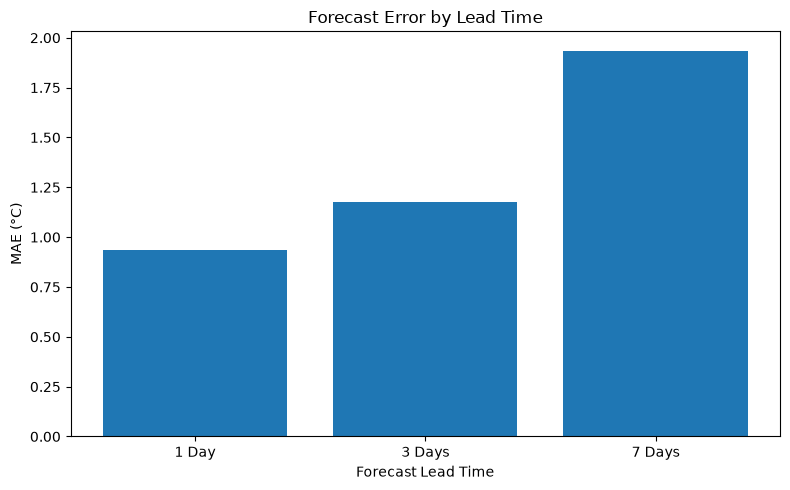

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    forecast_comparison["Lead Time"],
    forecast_comparison["MAE"]
)

plt.xlabel("Forecast Lead Time")
plt.ylabel("MAE (°C)")
plt.title("Forecast Error by Lead Time")

plt.tight_layout()
plt.show()

In [19]:
evaluation_df[
    [
        "date",
        "actual_max_temp",
        "forecast_1_day",
        "forecast_3_day",
        "forecast_7_day"
    ]
].head(15)

,date,actual_max_temp,forecast_1_day,forecast_3_day,forecast_7_day
0,2024-01-01,27.7,NaN,NaN,NaN
1,2024-01-02,27.3,NaN,NaN,NaN
2,2024-01-03,27.1,NaN,NaN,NaN
3,2024-01-04,27.7,NaN,NaN,NaN
4,2024-01-05,27.6,NaN,NaN,NaN
5,2024-01-06,27.9,NaN,NaN,NaN
6,2024-01-07,27.0,NaN,NaN,NaN
7,2024-01-08,27.4,NaN,NaN,NaN
8,2024-01-09,28.3,NaN,NaN,NaN
9,2024-01-10,26.0,NaN,NaN,NaN


In [20]:
evaluation_df.sort_values(
    "error_1_day",
    ascending=False
)[
    [
        "date",
        "actual_max_temp",
        "forecast_1_day",
        "error_1_day"
    ]
].head(10)

,date,actual_max_temp,forecast_1_day,error_1_day
525,2025-06-09,28.6,33.7,5.1
591,2025-08-14,27.4,23.0,4.4
127,2024-05-07,35.1,39.4,4.3
527,2025-06-11,30.1,25.9,4.2
173,2024-06-22,29.0,33.1,4.1
224,2024-08-12,28.2,32.3,4.1
102,2024-04-12,31.2,35.2,4.0
634,2025-09-26,27.7,23.7,4.0
252,2024-09-09,25.0,28.8,3.8
514,2025-05-29,30.9,27.1,3.8


In [21]:
print("Evaluation shape:", evaluation_df.shape)

print("\nMissing values:")
print(evaluation_df.isnull().sum())

print("\nMetrics:")
print(forecast_comparison)

Evaluation shape: (731, 8)

Missing values:
date                0
actual_max_temp     0
forecast_1_day     18
forecast_3_day     20
forecast_7_day     24
error_1_day        18
error_3_day        20
error_7_day        24
dtype: int64

Metrics:
  Lead Time       MAE       MSE      RMSE
0     1 Day  0.935344  1.557854  1.248140
1    3 Days  1.176512  2.314866  1.521468
2    7 Days  1.935502  6.304243  2.510825
